# Predict real data patches with previous models

In this notebook we are going to make some example predictions with the best models for the coast of Pollença.

#### Import necessary libraries

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio

import tensorflow as tf
from tensorflow.keras import Model, layers

import keras
import os

# Patterns code (0: fragmented seagrass, 1: meadow with holes, 2: homogeneous meadow, 3: Stripped meadow, 4: no seagrass)
patterns = {
    0: "Seagrass spots",
    1: "Meadow with holes",
    2: "Homogeneous meadow",
    3: "Striped meadow",
    4: "No seagrass",
}

#### Read a patch

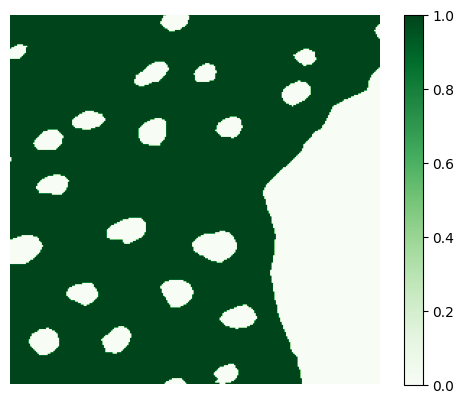

In [14]:
# Los que no son nada devuelven nan en el sitio, el resto da 0 o 1 si hay posidonia o no

ds = rasterio.open('data/patch_85_63.tif')

data = ds.read(1)

plt.imshow(data, cmap='Greens')

plt.axis('off')

plt.colorbar()

#### Predict the pattern

In [23]:
im_height=256
im_width=256

model_path = f"modelos/Cmodel_18.h5"
model = tf.keras.models.load_model(model_path)


# (hexagonos, hexagonos vacios, homogenea, rayas, vacia) = (0, 1, 2, 3, 4)
class_prediction = np.argmax(model.predict(data.reshape(1, im_height, im_width)))

prediction_name = patterns[class_prediction]

print("Predicted pattern: ", prediction_name)

1/1 [==============================] - 0s 120ms/step
Predicted pattern:  Meadow with holes


#### Predict the mortality

In [22]:
im_height=256
im_width=256

model_path = f"modelos/Dmodel_14.h5"
model = tf.keras.models.load_model(model_path)


mortality_prediction = model.predict(data.reshape(1, im_height, im_width))

print("Predicted mortality: ", mortality_prediction)

1/1 [==============================] - 0s 35ms/step
Predicted mortality:  [[0.22787383]]
